In [1]:
"""
Solar Lulls - 2026 Grad Colloquium Duration Risk
====================================
Description: This notebook will open swt data and assess when solar dorught is occuring in Australia and their associated risk.

Version History: 18/06/2026, written by Olivia Hugh-Jones

Notes:

"""

'\nSolar Lulls - 2026 Grad Colloquium Duration Risk\n====================================\nDescription: This notebook will open swt data and assess when solar dorught is occuring in Australia and their associated risk.\n\nVersion History: 18/06/2026, written by Olivia Hugh-Jones\n\nNotes:\n\n'

In [9]:
from pathlib import Path
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

In [5]:
risk = pd.read_csv("/scratch/nf33/oj9185/GC_26_Solar_lull/HACKATHON/event_risk_by_duration.csv")

In [6]:
low_count    = risk[risk['risk'] == 'low'].groupby('region').size().reset_index(name='low_count')
medium_count = risk[risk['risk'] == 'medium'].groupby('region').size().reset_index(name='medium_count')
high_count   = risk[risk['risk'] == 'high'].groupby('region').size().reset_index(name='high_count')

In [8]:
gdf = gpd.read_file('/scratch/nf33/ad1803/GC26_Solar_Lull/Training/Data/REZs/REZ_Map.shp')

In [14]:
rez_low = gdf.merge(low_count, left_on='name', right_on='region', how='left')
rez_medium = gdf.merge(medium_count, left_on='name', right_on='region', how='left')
rez_high = gdf.merge(high_count, left_on='name', right_on='region', how='left')

In [25]:
def plot_risk_map(gdf_plot, risk_level, count_col='low_count', vmax=600):
    
    fig = plt.figure(figsize=(10, 10))
    ax  = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())
    
    gdf_plot.plot(column=count_col, cmap='Reds', linewidth=0.5, edgecolor='black',
                  legend=False, ax=ax, transform=ccrs.PlateCarree(),
                  vmin=0, vmax=vmax,
                  missing_kwds={'color': 'lightgrey', 'edgecolor': 'black'})
    
    ax.coastlines(resolution='10m', linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.6)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False
    
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=mcolors.Normalize(vmin=0, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
    cbar.set_label('Number of Solar Lull Days')
    
    ax.set_title(f'{risk_level.capitalize()} Risk Solar Lull Days by Region')
    plt.tight_layout()
    plt.show()

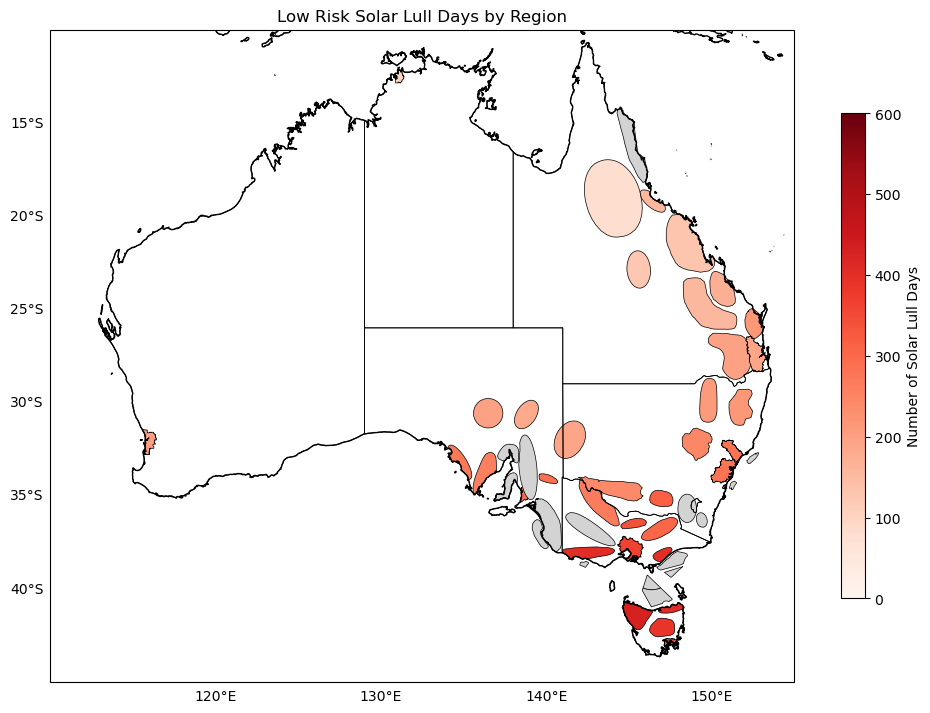

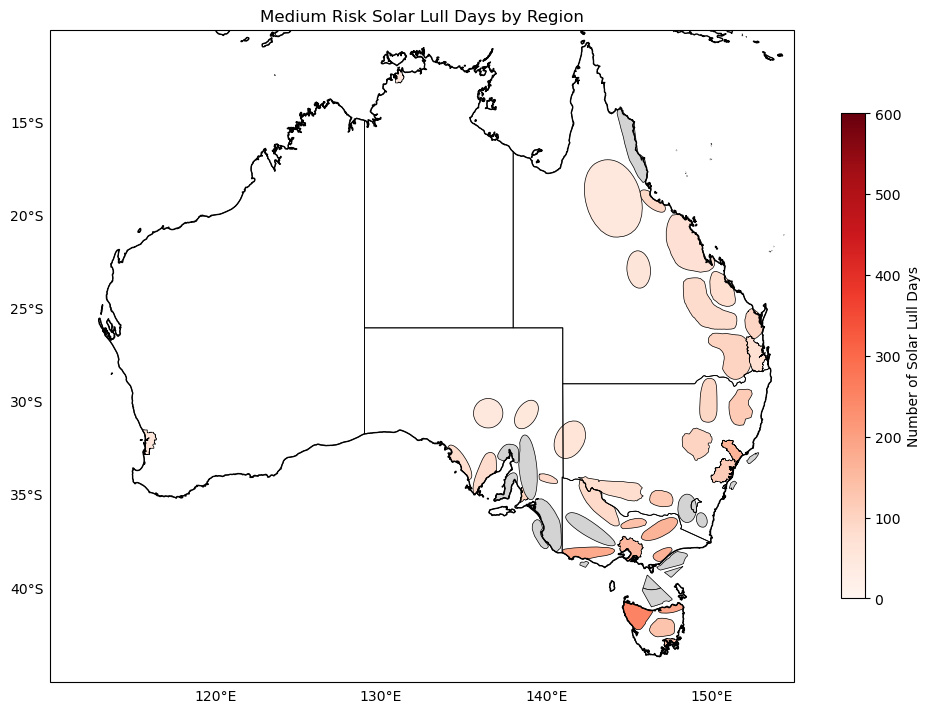

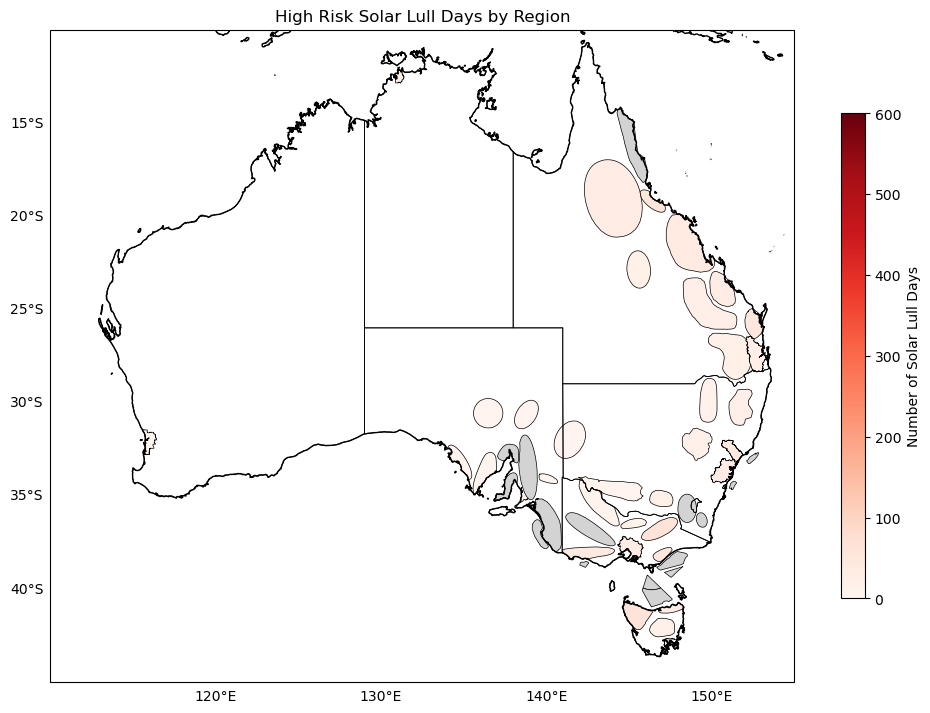

In [26]:
plot_risk_map(rez_low, 'low', count_col='low_count', vmax=600)
plot_risk_map(rez_medium, 'medium', count_col='medium_count', vmax=600)
plot_risk_map(rez_high, 'high', count_col='high_count', vmax=600)